# Patient transfer adaptation through a crisis: The dynamics of a Hospitals Network during the COVID-19 pandemic.

**Autores:** Cicchini Tomás, Salgado Ariel, Otero Lisandro, Goldman Mariano, Yacobitti Alejandro, Doldan Victoria, Kochen Silvia, Boechi Leonardo, Caridi Inés.

_Instituto del Cálculo (UBA-CONICET), Hospital de Alta Complejidad en Red Nestor Carlos Kirchner, ENYS (CONICET-HEC-UNAJ), y desarrollador free-lance._


In [3]:
import sys
sys.path.append("..")  # agrega raiz del proyecto al path

from scripts import bases, init_notebook as init


In [4]:
# Carga todos los datos del proyecto de una vez
ctx_datos = init.init_notebook(data_path="../data")

df_pacientes    = ctx_datos["df_pacientes"]
traslados       = ctx_datos["traslados"]
hosp_coords     = ctx_datos["hosp_coords"]
municipios      = ctx_datos["municipios"]
municipios_amba = ctx_datos["municipios_amba"]


Cargando datos de pacientes...
[reconstruir_traslados] Se descartaron 82 traslados con error grave de fechas.
  → 29,696 registros | 27,294 pacientes únicos
  → 1,681 traslados reconstruidos
Cargando datos geográficos...
  → 15 hospitales con coordenadas
  → 9 municipios AMBA cargados

✓ Entorno listo.

--- CHEQUEO POST-LIMPIEZA ---
Filas:              29696
Pacientes únicos:   27294
Hospitales únicos:  15
Valores nulos (Fecha inicio): 3168
Valores nulos (Fecha egreso): 4023

Distribución tipo_egreso:
tipo_egreso
alta           17519
traslado        5330
otro            3580
muerte          2791
desconocido      476
Name: count, dtype: int64

Distribución evolución:
evolucion
 0    27147
-1     1392
 1      944
-2      200
 2       13
Name: count, dtype: int64


## The hospital network and the data.

**Contexto:** El trabajo en red permite optimizar recursos en momentos críticos.  
**Impacto COVID-19:** La pandemia puso en crisis a los sistemas de salud y obligó a adaptar infraestructuras.  
**Red Sudeste:** El sistema informático recolectó datos de camas y traslados de 14 hospitales de la Red Sudeste. Abarca cuatro municipios: Quilmes (QU), Almirante Brown (AB), Florencio Varela (FV) y Berazategui (BE), cubriendo 661 km² y casi 2 millones de habitantes.


In [5]:
# Mapas (Paneles A, B y C)
# A. Aquí se visualiza la Provincia de Buenos Aires (PBA)

# ----------------------------
# cargar datos
# ----------------------------

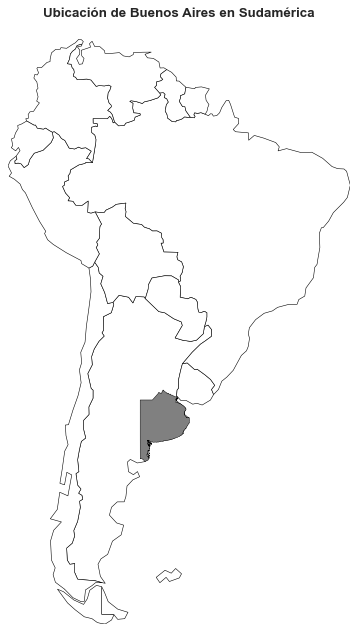

In [6]:
import geopandas as gpd
import matplotlib.pyplot as plt

# -------------------------
# 1. Cargar datos
# -------------------------
paises = gpd.read_file("../data/ne_countries/ne_110m_admin_0_countries.shp")
sudamerica = paises[paises["CONTINENT"] == "South America"]

provincias = gpd.read_file("../data/provincias_ign/provinciaPolygon.shp")
pba = provincias[provincias["nam"] == "Buenos Aires"]

# -------------------------
# 2. PROYECCIÓN (El truco para que no se vea estirado)
# -------------------------
# Pasamos de WGS84 (grados) a Web Mercator (metros), que es el estándar de mapas modernos
sudamerica = sudamerica.to_crs(epsg=3857)
pba = pba.to_crs(epsg=3857)

# -------------------------
# 3. Plot con mejoras estéticas
# -------------------------
# Aumentamos el DPI para que el trazo no se vea "pixelado" o de baja calidad
fig, ax = plt.subplots(figsize=(6, 8), dpi=80)

# Sudamérica (Fondo)
sudamerica.plot(
    ax=ax,
    color="white",      # Un gris muy claro para que no compita con PBA
    edgecolor="black",  # Un gris oscuro en lugar de negro puro (más elegante)
    linewidth=0.5        # Un poco más grueso para que se defina bien
)

# Buenos Aires resaltada
pba.plot(
    ax=ax,
    color="#808080",      # Un dimgray más sólido
    edgecolor="black",
    linewidth=0.4            # Asegura que esté por encima de las líneas de Sudamérica
)

# -------------------------
# 4. Ajustes de encuadre
# -------------------------
# Al cambiar a EPSG:3857, los límites ya no son grados, sino metros. 
# Es mejor dejar que GeoPandas calcule el zoom basado en Sudamérica:
minx, miny, maxx, maxy = sudamerica.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Título con mejor fuente
ax.set_title(
    "Ubicación de Buenos Aires en Sudamérica",
    fontsize=12,
    fontweight="bold",
    pad=20,
    loc="center"
)

ax.axis("off")

plt.tight_layout()
plt.show()

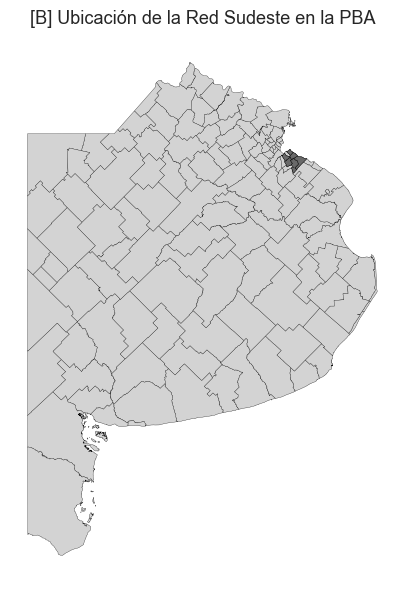

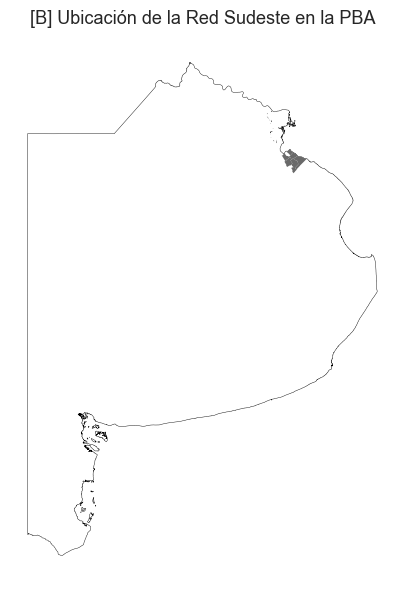

In [7]:
# -------------------------
# cargar municipios (partidos)
# -------------------------
deptos = bases.cargar_municipios("../data/shapefiles/departamento/departamentoPolygon.shp")

# solo partidos de la provincia de buenos aires
pba = deptos[
    deptos["in1"].astype(str).str.startswith("06")
]

# -------------------------
# partidos de la red sudeste
# -------------------------
red_sudeste = [
    "QUILMES", "ALMIRANTE BROWN", "FLORENCIO VARELA",
    "BERAZATEGUI", "LANUS", "LOMAS DE ZAMORA",
    "AVELLANEDA", "MORON", "ITUZAINGO"
]

sudeste = pba[pba["nam_limpio"].isin(red_sudeste)]

# =====================================================
# OPTION 1
# todos los partidos + red sudeste resaltada
# =====================================================

fig, ax = plt.subplots(figsize=(6,6))

# todos los partidos
pba.plot(
    ax=ax,
    color="lightgray",
    edgecolor="black",
    linewidth=0.2
)

# partidos de la red sudeste
sudeste.plot(
    ax=ax,
    color="dimgray",
    edgecolor="black",
    linewidth=0.3
)

ax.set_title(
    "[B] Ubicación de la Red Sudeste en la PBA",
    fontsize=13,
    pad=10
)

ax.axis("off")

plt.tight_layout()
plt.show()


# =====================================================
# OPTION 2
# provincia blanca sin divisiones + red sudeste
# =====================================================

# crear geometría de toda la provincia
pba_union = pba.dissolve()

fig, ax = plt.subplots(figsize=(6,6))

# provincia completa
pba_union.plot(
    ax=ax,
    color="white",
    edgecolor="black",
    linewidth=0.3
)

# partidos de la red
sudeste.plot(
    ax=ax,
    color="dimgray",
    edgecolor="none"
)

ax.set_title(
    "[B] Ubicación de la Red Sudeste en la PBA",
    fontsize=13,
    pad=10
)

ax.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# C. Los asentamientos cercanos

# RE.NA.BA.P

Cargando datos...
Proyectando a Web Mercator...
Cruzando capas...
Generando mapa...


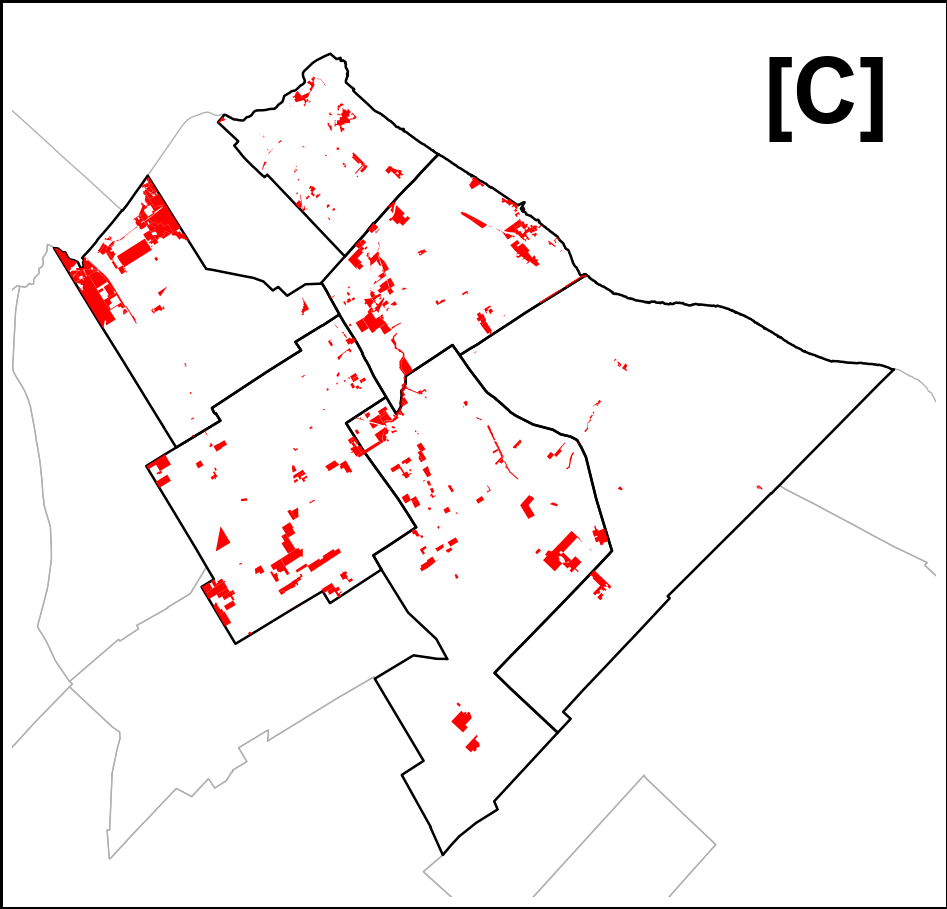

In [12]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ==============================================================================
# CONFIGURACIÓN Y CARGA DE DATOS
# ==============================================================================
# Rutas de los archivos proporcionadas por el usuario. 
# Asegúrate de que los archivos existan en estas ubicaciones.
RUTA_MUNICIPIOS = "../data/shapefiles/departamento/departamentoPolygon.shp"
RUTA_BARRIOS_POPULARES = "../data/renabap_geojson/20231205_info_publica.geojson.txt" # O usar el archivo GPKG si este falla
print("Cargando datos...")
deptos = gpd.read_file(RUTA_MUNICIPIOS)
barrios = gpd.read_file(RUTA_BARRIOS_POPULARES)

# Filtrar solo la PBA (códigos que empiezan con 06)
pba = deptos[deptos["in1"].astype(str).str.startswith("06")].copy()

# ==============================================================================
# 2. LIMPIEZA Y FILTRADO (LA SOLUCIÓN AL ERROR)
# ==============================================================================
# Creamos una columna limpia: todo a mayúsculas y sin tildes
pba["nam_limpio"] = (
    pba["nam"]
    .astype(str)
    .str.upper()
    .str.replace('Á', 'A')
    .str.replace('É', 'E')
    .str.replace('Í', 'I')
    .str.replace('Ó', 'O')
    .str.replace('Ú', 'U')
)

red_sudeste_names = [
    "QUILMES", "ALMIRANTE BROWN", "FLORENCIO VARELA",
    "BERAZATEGUI", "LANUS", "LOMAS DE ZAMORA",
    "AVELLANEDA", "MORON", "ITUZAINGO"
]

# Ahora sí filtramos de forma segura
sudeste = pba[pba["nam_limpio"].isin(red_sudeste_names)]

# Control de seguridad para evitar el error de NaN
if sudeste.empty:
    raise ValueError("¡Atención! El filtro sigue sin encontrar municipios. Revisa la columna 'nam' de tu shapefile.")

# ==============================================================================
# 3. PROYECCIÓN Y CRUCE ESPACIAL
# ==============================================================================
print("Proyectando a Web Mercator...")
pba = pba.to_crs(epsg=3857)
sudeste = sudeste.to_crs(epsg=3857)
barrios = barrios.to_crs(epsg=3857)

# Solo nos quedamos con los barrios que caen dentro de nuestros municipios
print("Cruzando capas...")
barrios_enfoque = gpd.clip(barrios, sudeste) 
# Nota: clip es más preciso visualmente que sjoin si un barrio cruza el límite

# ==============================================================================
# 4. GRAFICACIÓN EXACTA A LA IMAGEN
# ==============================================================================
print("Generando mapa...")
fig, ax = plt.subplots(figsize=(8, 8), dpi=120)

# A. Municipios de fondo (Gris clarito)
pba.plot(
    ax=ax,
    color="none",
    edgecolor="#B0B0B0", # Gris intermedio para los límites de fondo
    linewidth=0.8,
    zorder=1
)

# B. Municipios de la Red Sudeste (Borde negro grueso)
sudeste.plot(
    ax=ax,
    color="none",
    edgecolor="black",
    linewidth=1.5,      # Línea más gruesa para destacar
    zorder=2
)

# C. Barrios Populares (Rojo puro)
barrios_enfoque.plot(
    ax=ax,
    color="red",
    edgecolor="none",
    zorder=3
)

# ==============================================================================
# 5. AJUSTES FINALES (ZOOM Y TEXTO)
# ==============================================================================
ax.axis("off")

# Hacemos zoom en la zona de la red sudeste
minx, miny, maxx, maxy = sudeste.total_bounds
margen = 0.05 * (maxx - minx) # 5% de margen
ax.set_xlim(minx - margen, maxx + margen)
ax.set_ylim(miny - margen, maxy + margen)

# Agregamos la letra [C] arriba a la derecha (estilo igual a tu imagen)
ax.text(
    0.95, 0.95, 
    "[C]", 
    transform=ax.transAxes, 
    fontsize=55,           # Bien grande
    fontweight="bold", 
    color="black",         # Letra negra
    ha="right", 
    va="top",
    zorder=4
)

# El marco negro alrededor de toda la imagen (opcional pero está en tu foto)
fig.patch.set_linewidth(3)
fig.patch.set_edgecolor('black')

plt.tight_layout()
plt.show()